# Module 2 — Probability Models & Parametric Risk

In Notebook 1 we *described* returns — summary statistics, distribution shape, outliers. In this notebook we **fit a probability model** to those returns and use the model to answer two concrete questions:

1. **Quant application.** What's the probability that SBI returns more than 5% over the next week?
2. **Risk application.** How bad a loss should we be prepared for on a typical bad day? (Parametric Value at Risk.)

We continue with **SBI** and **Yes Bank**. Each step is broken out into its own cell.


## 0. Imports

We'll use the same stack as Notebook 1, plus `scipy.stats` for distribution-fitting and CDF/quantile functions.


In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 4)
pd.set_option('display.precision', 4)


## 1. Reload and prepare the data

This notebook is stand-alone, so we reload the CSVs and recompute daily and weekly returns. You saw the detailed step-by-step version of this in Notebook 1 — here we'll do the same thing more compactly, since you've already seen each step.


### 1.1  Load and clean SBI


In [59]:
sbi = pd.read_csv('datasets/daily/sbi.csv')
sbi['Date'] = pd.to_datetime(sbi['Date'], format='%d-%B-%Y')
sbi = sbi.sort_values('Date').set_index('Date')
sbi.head()


,Open Price,High Price,Low Price,Close Price,WAP,No.of Shares,No. of Trades,Total Turnover (Rs.),Deliverable Quantity,% Deli. Qty to Traded Qty,Spread High-Low,Spread Close-Open
Date,,,,,,,,,,,,
2025-04-30,812.85,812.85,784.45,788.15,792.8184,412886,13571,3.2734e+08,157049,38.04,28.40,-24.70
2025-05-02,792.05,802.95,789.25,800.05,795.9029,335006,8100,2.6663e+08,97358,29.06,13.70,8.00
2025-05-05,784.95,799.10,783.65,790.00,789.7475,771587,22047,6.0936e+08,292169,37.87,15.45,5.05
2025-05-06,792.20,799.00,771.15,774.15,778.2487,761282,23690,5.9247e+08,309770,40.69,27.85,-18.05
2025-05-07,762.25,782.55,762.25,776.15,775.8552,581175,14757,4.5091e+08,235513,40.52,20.30,13.90


### 1.2  Load and clean Yes Bank


In [60]:
yesbank = pd.read_csv('datasets/daily/YesBank.csv')
yesbank['Date'] = pd.to_datetime(yesbank['Date'], format='%d-%B-%Y')
yesbank = yesbank.sort_values('Date').set_index('Date')
yesbank.head()


,Open Price,High Price,Low Price,Close Price,WAP,No.of Shares,No. of Trades,Total Turnover (Rs.),Deliverable Quantity,% Deli. Qty to Traded Qty,Spread High-Low,Spread Close-Open
Date,,,,,,,,,,,,
2025-04-30,17.96,18.03,17.66,17.72,17.8296,7721231,17056,1.3767e+08,4.1017e+06,53.12,0.37,-0.24
2025-05-02,17.69,17.99,17.61,17.71,17.8084,7591714,16051,1.3520e+08,2.7774e+06,36.58,0.38,0.02
2025-05-05,17.71,17.84,17.51,17.73,17.7039,6614205,16396,1.1710e+08,2.7459e+06,41.51,0.33,0.02
2025-05-06,19.24,19.44,17.88,17.94,18.4596,39392027,41979,7.2716e+08,1.1603e+07,29.46,1.56,-1.30
2025-05-07,17.81,18.38,17.72,18.27,18.0418,17618432,24598,3.1787e+08,6.5962e+06,37.44,0.66,0.46


### 1.3  Compute daily simple returns


In [61]:
sbi['DailyReturn']     = sbi['Close Price'].pct_change()
yesbank['DailyReturn'] = yesbank['Close Price'].pct_change()

print('SBI daily observations:     ', sbi['DailyReturn'].dropna().shape[0])
print('Yes Bank daily observations:', yesbank['DailyReturn'].dropna().shape[0])


SBI daily observations:      241
Yes Bank daily observations: 241


### 1.4  Compute weekly simple returns via `resample`


In [62]:
sbi_weekly_price      = sbi['Close Price'].resample('W-FRI').last()
sbi_weekly_return     = sbi_weekly_price.pct_change()

yesbank_weekly_price  = yesbank['Close Price'].resample('W-FRI').last()
yesbank_weekly_return = yesbank_weekly_price.pct_change()

print('SBI weekly observations:     ', sbi_weekly_return.dropna().shape[0])
print('Yes Bank weekly observations:', yesbank_weekly_return.dropna().shape[0])


SBI weekly observations:      51
Yes Bank weekly observations: 51


### 1.5  Drop NaN and keep clean series

We'll work throughout with the NaN-dropped versions. Storing them in short names keeps later cells tidy.


In [63]:
sbi_daily      = sbi['DailyReturn'].dropna()
yesbank_daily  = yesbank['DailyReturn'].dropna()
sbi_weekly     = sbi_weekly_return.dropna()
yesbank_weekly = yesbank_weekly_return.dropna()

print('Shapes  (n observations):')
print(f'  SBI daily:      {len(sbi_daily):4d}    weekly: {len(sbi_weekly):3d}')
print(f'  Yes Bank daily: {len(yesbank_daily):4d}    weekly: {len(yesbank_weekly):3d}')


Shapes  (n observations):
  SBI daily:       241    weekly:  51
  Yes Bank daily:  241    weekly:  51


## 2. Why do we need a probability model?

A histogram tells us what *did* happen in our sample. A probability model lets us reason about what *could* happen — including events we haven't seen yet.

Specifically, once we have a fitted model $f(r; \theta)$ we can compute:

- **$P(R > \text{target})$** — the chance of beating a target return.
- **$P(R < -\text{loss})$** — the chance of a crash worse than some threshold.
- **Quantiles** — "how bad a day should I be prepared for, with 95% confidence?" → this is **Value at Risk**.

The choice of $f$ matters. If we pick a distribution that's too thin-tailed, we'll **under-estimate** crash probabilities.

In this notebook we'll fit two distributions — the **normal** and the **Student-t** — and compare.


## 3. Fitting a normal distribution

A normal distribution has two parameters: mean $\mu$ and standard deviation $\sigma$. The **maximum-likelihood estimates** (MLE) for the normal are just the sample mean and the sample standard deviation:

$$
\hat{\mu} = \bar{r}, \qquad \hat{\sigma} = s
$$

So no heavy machinery is needed — just `.mean()` and `.std()`.


### 3.1  Estimate $\mu$ and $\sigma$ for SBI daily returns


In [64]:
mu_sbi    = sbi_daily.mean()
sigma_sbi = sbi_daily.std()
print(f'SBI daily:      mu = {mu_sbi:+.6f}   sigma = {sigma_sbi:.6f}')


SBI daily:      mu = +0.001518   sigma = 0.013285


### 3.2  Estimate $\mu$ and $\sigma$ for Yes Bank daily returns


In [65]:
mu_yb    = yesbank_daily.mean()
sigma_yb = yesbank_daily.std()
print(f'Yes Bank daily: mu = {mu_yb:+.6f}   sigma = {sigma_yb:.6f}')


Yes Bank daily: mu = +0.000630   sigma = 0.018931


### 3.3  Overlay the fitted normal PDF on each histogram

The PDF of $\mathcal{N}(\mu, \sigma^2)$ at a point $x$ is `stats.norm.pdf(x, loc=μ, scale=σ)`. We'll evaluate it on a grid and overlay it on the empirical histogram.


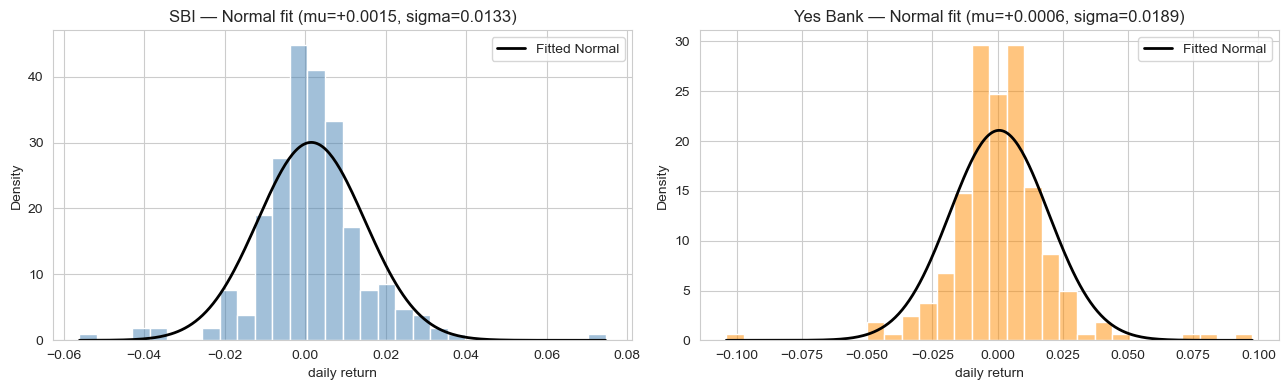

In [86]:
# Grids for plotting the fitted PDFs
x_sbi = np.linspace(sbi_daily.min(), sbi_daily.max(), 300)
x_yb  = np.linspace(yesbank_daily.min(), yesbank_daily.max(), 300)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(sbi_daily, bins=30, stat='density',
             color='steelblue', alpha=0.5, ax=axes[0])
axes[0].plot(x_sbi, stats.norm.pdf(x_sbi, loc=mu_sbi, scale=sigma_sbi),
             'k-', linewidth=2, label='Fitted Normal')
axes[0].set_title(f'SBI — Normal fit (mu={mu_sbi:+.4f}, sigma={sigma_sbi:.4f})')
axes[0].set_xlabel('daily return'); axes[0].legend()

sns.histplot(yesbank_daily, bins=30, stat='density',
             color='darkorange', alpha=0.5, ax=axes[1])
axes[1].plot(x_yb, stats.norm.pdf(x_yb, loc=mu_yb, scale=sigma_yb),
             'k-', linewidth=2, label='Fitted Normal')
axes[1].set_title(f'Yes Bank — Normal fit (mu={mu_yb:+.4f}, sigma={sigma_yb:.4f})')
axes[1].set_xlabel('daily return'); axes[1].legend()

plt.tight_layout()
plt.show()


**What to notice.** The normal captures the **centre** reasonably well but the histogram has more mass in the **extreme tails** than the black curve suggests. Real returns have fatter tails than a normal would predict — a classic empirical fact.


## 4. Fitting a Student-t distribution

The Student-t distribution has three parameters:

- **$\nu$ (degrees of freedom)** — controls tail thickness. Small $\nu$ → very fat tails. Large $\nu$ → approaches the normal.
- **$\mu$ (location)** — similar to the normal's mean.
- **$\sigma$ (scale)** — similar to the normal's std (but not identical: the variance of a t is $\sigma^2 \cdot \nu / (\nu - 2)$ for $\nu > 2$).

Unlike the normal, there's no closed-form MLE for all three parameters, so `scipy.stats.t.fit` uses numerical optimisation.


### 4.1  Fit the Student-t to SBI daily


In [87]:
df_sbi, loc_sbi, scale_sbi = stats.t.fit(sbi_daily)
print(f'SBI daily t-fit:  df = {df_sbi:.4f}   loc = {loc_sbi:+.6f}   scale = {scale_sbi:.6f}')


SBI daily t-fit:  df = 2.9626   loc = +0.001205   scale = 0.008311


A small `df` (say, single digits) means heavy tails. A df above ~30 is essentially normal.


### 4.2  Fit the Student-t to Yes Bank daily


In [88]:
df_yb, loc_yb, scale_yb = stats.t.fit(yesbank_daily)
print(f'Yes Bank daily t-fit:  df = {df_yb:.4f}   loc = {loc_yb:+.6f}   scale = {scale_yb:.6f}')


Yes Bank daily t-fit:  df = 2.9647   loc = +0.000178   scale = 0.011355


### 4.3  Overlay Normal and Student-t PDFs on each histogram

Now both fitted curves, side by side, over each stock's histogram.


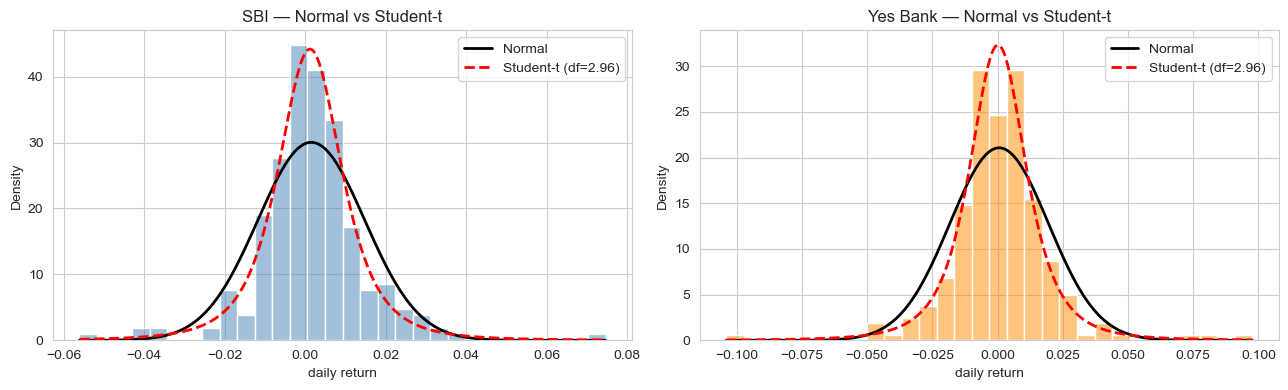

In [89]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(sbi_daily, bins=30, stat='density',
             color='steelblue', alpha=0.5, ax=axes[0])
axes[0].plot(x_sbi, stats.norm.pdf(x_sbi, loc=mu_sbi, scale=sigma_sbi),
             'k-',  linewidth=2, label='Normal')
axes[0].plot(x_sbi, stats.t.pdf(x_sbi, df_sbi, loc=loc_sbi, scale=scale_sbi),
             'r--', linewidth=2, label=f'Student-t (df={df_sbi:.2f})')
axes[0].set_title('SBI — Normal vs Student-t')
axes[0].set_xlabel('daily return'); axes[0].legend()

sns.histplot(yesbank_daily, bins=30, stat='density',
             color='darkorange', alpha=0.5, ax=axes[1])
axes[1].plot(x_yb, stats.norm.pdf(x_yb, loc=mu_yb, scale=sigma_yb),
             'k-',  linewidth=2, label='Normal')
axes[1].plot(x_yb, stats.t.pdf(x_yb, df_yb, loc=loc_yb, scale=scale_yb),
             'r--', linewidth=2, label=f'Student-t (df={df_yb:.2f})')
axes[1].set_title('Yes Bank — Normal vs Student-t')
axes[1].set_xlabel('daily return'); axes[1].legend()

plt.tight_layout()
plt.show()


**What to notice.** The red dashed (t) curve is **more peaked at the centre** and **heavier in the tails** than the black (normal) curve. That's exactly the shape real returns tend to have.


## 5. Quant application — probability of beating a target return

**Question.** An investor asks: *"What's the probability that SBI delivers more than a 5% return over the next week?"*

With a fitted model this becomes a straightforward CDF look-up:

$$
P(R_{\text{weekly}} > \text{target}) = 1 - F(\text{target})
$$

where $F$ is the CDF of our fitted distribution.

We'll answer under **both** the normal and the Student-t model, and see how the answers differ.


### 5.1  Fit the Normal to SBI's weekly returns


In [70]:
mu_sbi_w    = sbi_weekly.mean()
sigma_sbi_w = sbi_weekly.std()
print(f'SBI weekly (Normal):    mu = {mu_sbi_w:+.6f}   sigma = {sigma_sbi_w:.6f}')


SBI weekly (Normal):    mu = +0.006903   sigma = 0.029630


### 5.2  Fit the Student-t to SBI's weekly returns


In [71]:
df_sbi_w, loc_sbi_w, scale_sbi_w = stats.t.fit(sbi_weekly)
print(f'SBI weekly (t-fit):     df = {df_sbi_w:.4f}  loc = {loc_sbi_w:+.6f}  scale = {scale_sbi_w:.6f}')


SBI weekly (t-fit):     df = 3.0398  loc = +0.006556  scale = 0.018358


### 5.3  P(weekly return > 5%) — Normal model


In [72]:
target = 0.05
p_sbi_normal = 1 - stats.norm.cdf(target, loc=mu_sbi_w, scale=sigma_sbi_w)
print(f'SBI — Normal model: P(weekly return > {target:.0%}) = {p_sbi_normal:.4f}  ({p_sbi_normal*100:.2f}%)')


SBI — Normal model: P(weekly return > 5%) = 0.0729  (7.29%)


### 5.4  P(weekly return > 5%) — Student-t model


In [73]:
p_sbi_t = 1 - stats.t.cdf(target, df_sbi_w, loc=loc_sbi_w, scale=scale_sbi_w)
print(f'SBI — Student-t model: P(weekly return > {target:.0%}) = {p_sbi_t:.4f}  ({p_sbi_t*100:.2f}%)')


SBI — Student-t model: P(weekly return > 5%) = 0.0488  (4.88%)


### 5.5  Repeat the same four steps for Yes Bank


**Why do the two models disagree?**

Out in the right tail (> 5% weekly return, which is a rare event), the Student-t has **more probability mass** than the normal. So the t-model reports a **higher** probability of beating the target.

The story is symmetric — in the *left* tail (very bad losses), the t-model also puts more mass. That's the connection to our next topic: **Value at Risk**.

> **Intermediate exercise 7.1**
>
> Repeat §7.3 and §7.4 for targets of **2%, 5%, 10%**. Make a small table: rows = targets, columns = Normal / Student-t. For which targets do the two models agree? Where do they diverge most?


## 6. Risk application — parametric Value at Risk

**Value at Risk (VaR)** at confidence level $1 - \alpha$ is the loss level that will be exceeded with probability only $\alpha$.

- 1-day 95% VaR: the loss you'd exceed on about 1 day in 20.
- 1-day 99% VaR: the loss you'd exceed on about 1 day in 100.

For a return $R \sim F$, the VaR is defined by

$$
P(R < -\text{VaR}_\alpha) = \alpha
$$

Rearranging, $-\text{VaR}_\alpha = F^{-1}(\alpha)$ — the $\alpha$-quantile of the return distribution. We report **VaR as a positive loss number**.

Under a fitted distribution, $F^{-1}$ is the `ppf` (percent-point function) in scipy.


### 6.1  SBI — 1-day 95% VaR under the Normal model


In [90]:
from scipy.stats import norm

q_sbi_normal_95, _ = norm.interval(confidence=0.90, loc=mu_sbi, scale=sigma_sbi)

var_sbi_normal_95 = -q_sbi_normal_95
print(f'SBI 1-day 95% VaR (Normal): {var_sbi_normal_95:.4f}  ({var_sbi_normal_95*100:.2f}%)')


SBI 1-day 95% VaR (Normal): 0.0203  (2.03%)


**Interpretation.** On a typical day, we'd expect a loss worse than `{:.2%}` (say) on only 5 days out of 100.


### 6.2  SBI — 1-day 99% VaR under the Normal model


In [91]:
q_sbi_normal_99, _ = norm.interval(confidence=0.98, loc=mu_sbi, scale=sigma_sbi)
var_sbi_normal_99 = -q_sbi_normal_99
print(f'SBI 1-day 99% VaR (Normal): {var_sbi_normal_99:.4f}  ({var_sbi_normal_99*100:.2f}%)')


SBI 1-day 99% VaR (Normal): 0.0294  (2.94%)


### 6.3  SBI — same two VaRs under the Student-t model


In [92]:
from scipy.stats import t

q_sbi_t_95, _ = t.interval(0.90, df_sbi, loc=loc_sbi, scale=scale_sbi)
q_sbi_t_99, _ = t.interval(0.98, df_sbi, loc=loc_sbi, scale=scale_sbi)
var_sbi_t_95 = -q_sbi_t_95
var_sbi_t_99 = -q_sbi_t_99
print(f'SBI 1-day 95% VaR (t): {var_sbi_t_95:.4f}  ({var_sbi_t_95*100:.2f}%)')
print(f'SBI 1-day 99% VaR (t): {var_sbi_t_99:.4f}  ({var_sbi_t_99*100:.2f}%)')


SBI 1-day 95% VaR (t): 0.0185  (1.85%)
SBI 1-day 99% VaR (t): 0.0369  (3.69%)


### 6.4  Yes Bank — all four VaRs in one cell


In [94]:
# Participants to complete this exercise

# var_yb_normal_95, _ = 
# var_yb_normal_99, _ = 
# var_yb_t_95, _      = 
# var_yb_t_99, _      = 

var_yb_normal_95 = -var_yb_normal_95
var_yb_normal_99 = -var_yb_normal_99
var_yb_t_95 = -var_yb_t_95
var_yb_t_99 = -var_yb_t_99


print(f'Yes Bank 1-day 95% VaR (Normal): {var_yb_normal_95:.4f}  ({var_yb_normal_95*100:.2f}%)')
print(f'Yes Bank 1-day 99% VaR (Normal): {var_yb_normal_99:.4f}  ({var_yb_normal_99*100:.2f}%)')
print(f'Yes Bank 1-day 95% VaR (t):      {var_yb_t_95:.4f}  ({var_yb_t_95*100:.2f}%)')
print(f'Yes Bank 1-day 99% VaR (t):      {var_yb_t_99:.4f}  ({var_yb_t_99*100:.2f}%)')


Yes Bank 1-day 95% VaR (Normal): 0.0305  (3.05%)
Yes Bank 1-day 99% VaR (Normal): 0.0434  (4.34%)
Yes Bank 1-day 95% VaR (t):      0.0267  (2.67%)
Yes Bank 1-day 99% VaR (t):      0.0519  (5.19%)


### 6.5  A compact comparison table


In [80]:
var_table = pd.DataFrame({
    'Normal 95%':    [var_sbi_normal_95, var_yb_normal_95],
    'Student-t 95%': [var_sbi_t_95,      var_yb_t_95],
    'Normal 99%':    [var_sbi_normal_99, var_yb_normal_99],
    'Student-t 99%': [var_sbi_t_99,      var_yb_t_99],
}, index=['SBI', 'Yes Bank'])
var_table.style.format('{:.2%}')


,Normal 95%,Student-t 95%,Normal 99%,Student-t 99%
SBI,2.03%,1.85%,2.94%,3.69%
Yes Bank,3.05%,2.67%,4.34%,5.19%


**What to notice.** At the 99% level, the Student-t VaR is **larger** (more conservative) than the Normal VaR. This is the fat-tail story: normal VaR *under-estimates* extreme-loss risk.

The gap is bigger at 99% than at 95% — because we're further into the tail.


## 7. Backtesting VaR — did our model's prediction hold up?

If we've built a 95% VaR estimate, **about 5%** of historical days should have losses exceeding that VaR. Many more → the model under-estimates risk. Many fewer → the model over-estimates.

A **VaR breach** is a day where the actual return was worse than negative-VaR.


### 7.1  Expected vs observed breaches — SBI Normal VaR


In [81]:
n_sbi = len(sbi_daily)

breach_sbi_normal_95 = (sbi_daily < -var_sbi_normal_95).sum()
breach_sbi_normal_99 = (sbi_daily < -var_sbi_normal_99).sum()

print(f'SBI n = {n_sbi}')
print(f'  Normal 95% VaR: expected ~{0.05*n_sbi:.1f} breaches   observed {breach_sbi_normal_95}')
print(f'  Normal 99% VaR: expected ~{0.01*n_sbi:.1f} breaches   observed {breach_sbi_normal_99}')


SBI n = 241
  Normal 95% VaR: expected ~12.1 breaches   observed 7
  Normal 99% VaR: expected ~2.4 breaches   observed 5


### 7.2  SBI Student-t VaR breaches


In [82]:
breach_sbi_t_95 = (sbi_daily < -var_sbi_t_95).sum()
breach_sbi_t_99 = (sbi_daily < -var_sbi_t_99).sum()

print(f'  Student-t 95% VaR: expected ~{0.05*n_sbi:.1f} breaches   observed {breach_sbi_t_95}')
print(f'  Student-t 99% VaR: expected ~{0.01*n_sbi:.1f} breaches   observed {breach_sbi_t_99}')


  Student-t 95% VaR: expected ~12.1 breaches   observed 13
  Student-t 99% VaR: expected ~2.4 breaches   observed 4


### 7.3  Same four counts for Yes Bank


>
> Compute the **VaR** for Yes Bank.


## 8. Non-parametric VaR and a three-way comparison

There's a third, model-free way to estimate VaR: just take the empirical $\alpha$-quantile of the historical returns. This is called **historical VaR**.

- Pros: no distributional assumption.
- Cons: entirely driven by what's already in your sample; no way to extrapolate beyond the worst day you've seen.


### 8.1  Historical VaR for SBI


In [83]:
hist_var_sbi_95 = -sbi_daily.quantile(0.05)
hist_var_sbi_99 = -sbi_daily.quantile(0.01)
print(f'SBI historical 95% VaR: {hist_var_sbi_95:.4f}  ({hist_var_sbi_95*100:.2f}%)')
print(f'SBI historical 99% VaR: {hist_var_sbi_99:.4f}  ({hist_var_sbi_99*100:.2f}%)')


SBI historical 95% VaR: 0.0190  (1.90%)
SBI historical 99% VaR: 0.0388  (3.88%)


### 8.2  Historical VaR for Yes Bank


### 8.4  Visualise — where does each VaR sit on the histogram?

For SBI, we'll mark the three 99% VaR estimates on a single histogram. The three vertical lines typically sit *within a few tenths of a percent of each other* — but those small differences are the whole point of the methodology.


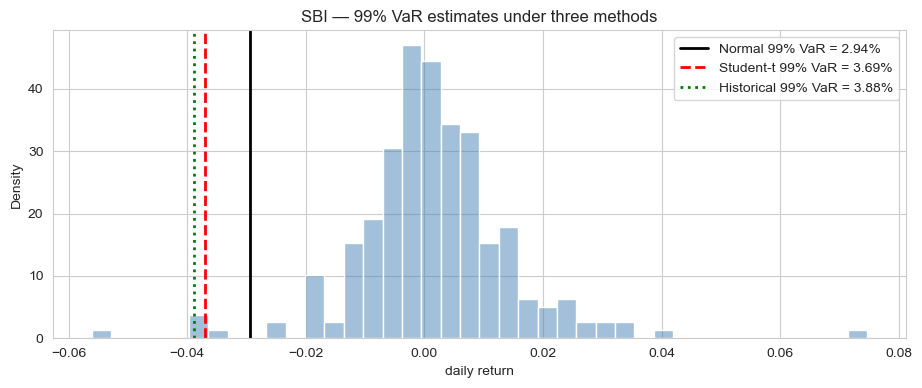

In [84]:
fig, ax = plt.subplots(figsize=(11, 4))
sns.histplot(sbi_daily, bins=40, stat='density',
             color='steelblue', alpha=0.5, ax=ax)

ax.axvline(-var_sbi_normal_99, color='k',       linestyle='-',  linewidth=2,
           label=f'Normal 99% VaR = {var_sbi_normal_99:.2%}')
ax.axvline(-var_sbi_t_99,      color='r',       linestyle='--', linewidth=2,
           label=f'Student-t 99% VaR = {var_sbi_t_99:.2%}')
ax.axvline(-hist_var_sbi_99,   color='green',   linestyle=':',  linewidth=2,
           label=f'Historical 99% VaR = {hist_var_sbi_99:.2%}')

ax.set_title('SBI — 99% VaR estimates under three methods')
ax.set_xlabel('daily return')
ax.legend()
plt.show()


> **Intermediate exercise 8.1**
>
> Produce the same plot for **Yes Bank** at the **95%** level. Which method is most conservative?


---

## End-of-notebook exercises

### Exercise 1 — Apply everything to Godrej

Load `godrej.csv` using the same steps from §1, then replicate:

- The Normal and Student-t fit tables (§3, §4).
- Visual goodness-of-fit (PDF overlays) for both distributions.
- The P(weekly return > 5%) calculation under both models.
- The three 99% VaR estimates (Normal / t / Historical) and how many days breached each.

Write a 2–3 sentence comment on which distribution fits Godrej better than the normal, and by how much the three VaR methods disagree.

### Exercise 2 — Weekly VaR instead of daily

Redo §6 using **weekly** returns for both stocks. Compare:

- Weekly 95% VaR fit directly to weekly returns.
- Weekly VaR scaled from daily parameters as $\sigma_{\text{daily}} \cdot \sqrt{5}$ and $\mu_{\text{daily}} \cdot 5$.

Do the two weekly VaR estimates agree? When would the "square-root-of-time" scaling rule break down?

### Exercise 3 — VaR as a function of confidence level

For SBI daily under the Student-t, plot **VaR on the y-axis vs $1 - \alpha$ on the x-axis** from 0.90 up to 0.995. Overlay the same curve for the Normal and for the Historical method. Where do the three curves start to diverge meaningfully?

### Exercise 4 — A different distribution

Try fitting a **Laplace** distribution (`stats.laplace`) to SBI's daily returns. It has only two parameters and much heavier tails than the normal. Compare its PDF overlay against the Normal and Student-t fits. Is it a competitive fit?

### Exercise 5 — Equal-weighted portfolio

Build a daily return series for a portfolio that is 50% SBI and 50% Yes Bank:

```
port_daily = 0.5 * sbi_daily + 0.5 * yesbank_daily
```

(You'll need to `.dropna()` and align by date first.) Fit a Normal and a Student-t to the portfolio return and compute its 95% and 99% VaR. Compare the portfolio's VaR to a simple weighted average of the individual VaRs — **diversification** should make the portfolio VaR *smaller*. Is it?

